<a href="https://colab.research.google.com/github/genaiconference/When-Agents-Meet-Living-Graphs/blob/main/Graphiti_The_Living_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Living Graph

### Why Graphiti is the memory layer every enterprise AI agent has been waiting for.

> Your knowledge graph is dying the moment you finish building it.
>
> The world keeps moving. Customers change roles. Contracts get renegotiated. Risks emerge. Vendors get acquired. Policies get updated.
>
> A static graph is a museum. An enterprise needs a graph that **breathes**.

Welcome to the **living graph**.

In this session you will see how **Graphiti**, the temporal knowledge graph framework from **Zep AI**, turns a knowledge graph from a static artifact into a real-time, bi-temporal, hybrid-retrieval memory layer for AI agents.

## What you will see

By the end of this notebook, you will have experienced all of Graphiti's headline features through a live enterprise scenario:

1. **Episodic ingestion**, knowledge arrives in small chunks called episodes, like memory in humans.
2. **Automatic entity and edge extraction**, structured knowledge from unstructured text.
3. **Bi-temporal model**, every fact carries both *when it became true* and *when we learned it*.
4. **Fact invalidation**, new information supersedes old, but the past is never erased.
5. **Hybrid retrieval**, semantic, keyword, and graph traversal in one call.
6. **Custom entity types**, domain-specific schemas (Customer, Contract, Risk, Person, Product).
7. **Community detection**, the natural clusters in your enterprise emerge automatically.
8. **Audit trails**, full provenance of every claim the agent ever makes.

The scenario: a real customer relationship that **evolves over six months**. Watch the graph live.

> Hack session talking point: this is the difference between "I have a knowledge graph" and "I have an agent that remembers."


## 1. The death of static knowledge

Every enterprise knowledge graph project goes through the same arc:

1. Quarter 1: extract entities from the corpus, marvel at how it works.
2. Quarter 2: ship to a few teams, marvel at how useful it is.
3. Quarter 3: realize the data is stale.
4. Quarter 4: budget for a "refresh pipeline" no one wants to own.

The graph dies. Not because the technology is bad, but because **the model is wrong**. Reality is temporal, the graph was not.

| Need                                  | Static KG    | Vector store | GraphRAG     | **Living graph (Graphiti)** |
| ------------------------------------- | :----------: | :----------: | :----------: | :-------------------------: |
| Add a single new fact in real time    |      no      |  partially   |      no      |         **yes**             |
| Track when a fact became true         |      no      |      no      |      no      |         **yes**             |
| Track when we learned the fact        |      no      |   partial    |      no      |         **yes**             |
| Invalidate without losing audit       |      no      |      no      |      no      |         **yes**             |
| Hybrid retrieval out of the box       |      no      |   semantic   |    partial   |         **yes**             |
| Re-derive past states                 |      no      |      no      |      no      |         **yes**             |
| Discover communities incrementally    |      no      |      no      |    batch     |         **yes**             |
| Power autonomous agents               |   limited    |   limited    |   limited    |         **yes**             |

The shift is not "graph vs vector". The shift is **static vs living**.


## 2. Enter Graphiti, the living graph

[Graphiti](https://github.com/getzep/graphiti) is an open source framework from **Zep AI**, the team behind one of the most adopted memory layers for LLM agents.

It treats your knowledge graph as a **stream of episodes**, not a static document set. Every episode:

- adds new entities and edges,
- timestamps every claim with both `valid_from` and `recorded_at`,
- automatically **invalidates** older claims that the new episode contradicts,
- and updates retrieval indexes incrementally, with no batch reprocessing.

That is what we mean by living.

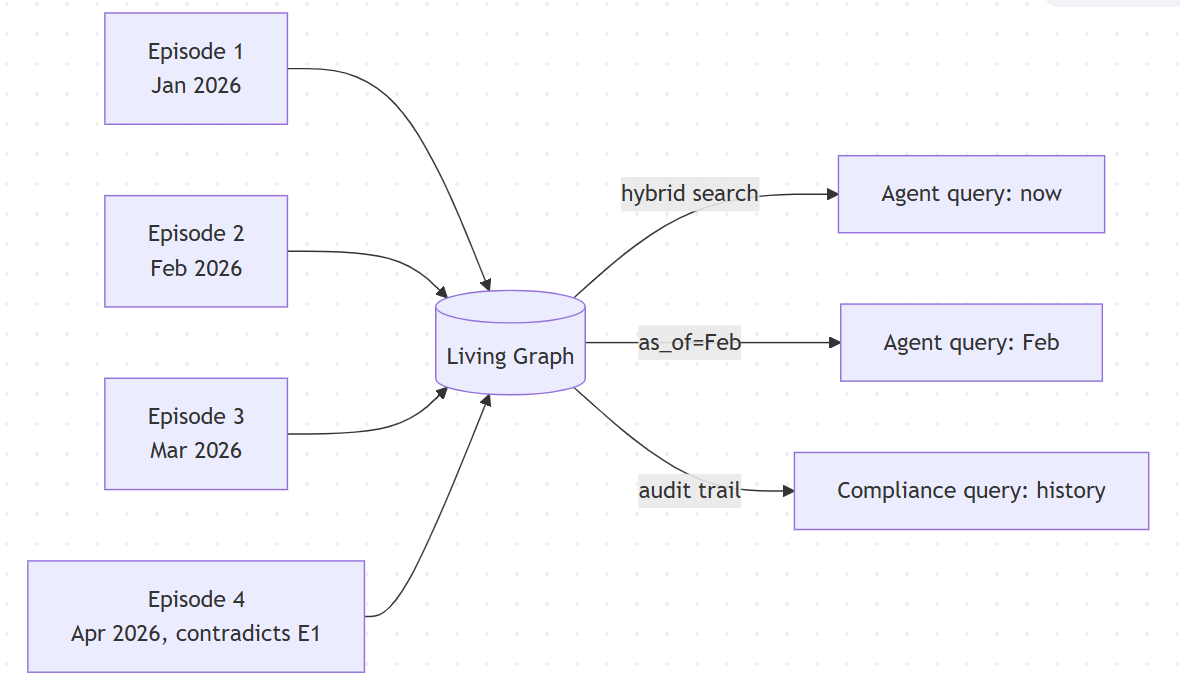

### Who is this for

- **Customer support agents** that need to know what the customer told you last week.
- **Compliance agents** that must show *what they knew, when*.
- **Sales agents** that need to know the latest contract terms but also the original ones.
- **Healthcare agents** that must reason over patient timelines.
- **Risk agents** that must track how risks evolve.

If your agent will be wrong if it does not remember, you need a living graph.


## 3. Setup, no secrets required

We deliberately avoid `.env` files and `requirements.txt`. Everything is inline. The cell below detects what you have and prints the active execution mode.

If you want to upgrade to **real Graphiti** later, uncomment the `%pip install` line. If you want to mirror writes to **Neo4j**, edit the inline constants. Otherwise just run the cells.


In [ ]:
# Optional upgrade paths, uncomment if you want them:
# %pip install -q graphiti-core neo4j
#
# Once installed, the cells in Section 16 will switch to the real Graphiti
# async API. Until then, our LivingGraph engine demonstrates the exact same
# concepts so the notebook runs end to end.

In [ ]:
# ---- Standard imports ----
import re
import json
import uuid
import textwrap
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import Markdown, display

# ---- Inline configuration. Edit if you want Neo4j mirroring ----
# Leave any field blank to skip Neo4j (the notebook still runs end to end).
NEO4J_URI      = ""        # e.g. "neo4j://localhost:7687"
NEO4J_USERNAME = ""        # e.g. "neo4j"
NEO4J_PASSWORD = ""        # e.g. "test1234"
NEO4J_DATABASE = "neo4j"

# ---- Detect optional dependencies ----
try:
    from neo4j import GraphDatabase
    _NEO4J_LIB = True
except Exception:
    _NEO4J_LIB = False

try:
    import graphiti_core  # noqa: F401
    _GRAPHITI_LIB = True
except Exception:
    _GRAPHITI_LIB = False

USE_NEO4J = bool(_NEO4J_LIB and NEO4J_URI and NEO4J_USERNAME and NEO4J_PASSWORD)
USE_REAL_GRAPHITI = bool(_GRAPHITI_LIB and USE_NEO4J)

mode = [
    f"Graphiti engine : {'real graphiti-core' if USE_REAL_GRAPHITI else 'LivingGraph simulator (faithful to Graphiti semantics)'}",
    f"Graph backend   : {'Neo4j ' + NEO4J_URI if USE_NEO4J else 'NetworkX (in-memory)'}",
    f"LLM extraction  : deterministic patterns (no API key needed)",
]
print("Active execution mode")
print("=====================")
print("\n".join(mode))

## 4. Building the living graph engine

To make the notebook work without external services, we implement `LivingGraph`, a faithful simulator of Graphiti's core semantics:

- `add_episode(name, body, reference_time, ...)` ingests a chunk of knowledge.
- Entities and facts are extracted (in real Graphiti by an LLM, here by deterministic patterns so the demo is reproducible).
- Every fact carries `valid_from`, `valid_to`, `recorded_at`, `invalidated_at`, `invalidated_by`.
- Adding a fact `(source, predicate, *)` automatically **invalidates** previous facts with the same `(source, predicate)` and a different target.
- `search()` does hybrid retrieval: entity match + keyword overlap + 1-hop graph expansion.
- `audit_trail()` returns every state a relationship ever had, including invalidated ones.
- `detect_communities()` finds natural clusters using modularity.

If you have Neo4j configured, every write is mirrored there with idempotent `MERGE` so re-runs are safe.

```mermaid
flowchart TB
    Ep[Episode\nname + body + reference_time] --> X[Extract entities + facts]
    X --> I{Existing\nsource+predicate?}
    I -->|yes, different target| Inv[Mark old fact\nvalid_to + invalidated_at]
    I -->|no| Skip[ ]
    Inv --> NF[Persist new fact\nvalid_from + recorded_at]
    Skip --> NF
    NF --> G[(Living Graph\nNetworkX + optional Neo4j)]
    G --> S[search / audit_trail / facts_as_of / detect_communities]
```


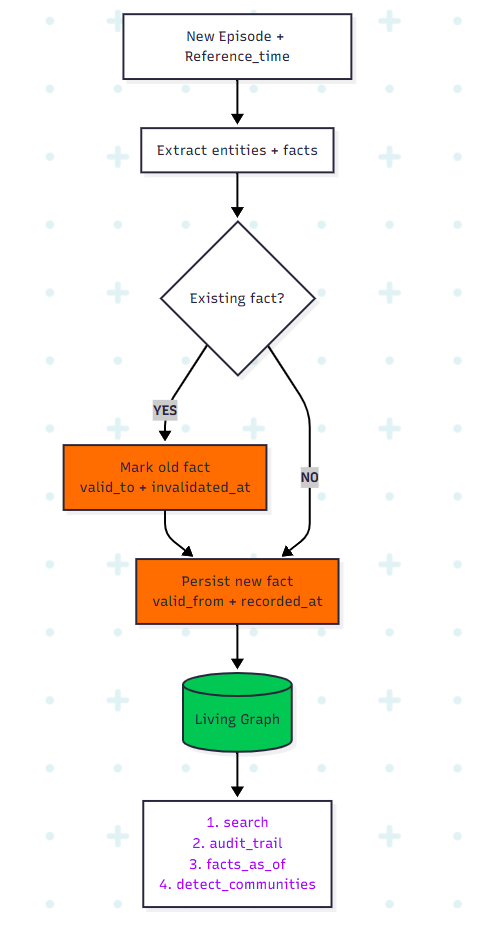

In [ ]:
@dataclass
class TemporalFact:
    """A bi-temporal edge: a claim about the world with full provenance."""
    id: str
    source: str
    predicate: str
    target: str
    episode_id: str
    valid_from: datetime         # when the fact became true in the world
    recorded_at: datetime        # when our system learned about it
    source_text: str = ""        # the natural-language snippet it came from
    valid_to: Optional[datetime] = None       # when it stopped being true
    invalidated_at: Optional[datetime] = None # when our system found out it was no longer true
    invalidated_by: Optional[str] = None      # the fact id that superseded this one

    @property
    def is_current(self) -> bool:
        return self.invalidated_at is None and self.valid_to is None

    def to_row(self) -> Dict[str, Any]:
        return {
            "fact_id":     self.id,
            "source":      self.source,
            "predicate":   self.predicate,
            "target":      self.target,
            "valid_from":  self.valid_from.date().isoformat(),
            "valid_to":    self.valid_to.date().isoformat() if self.valid_to else "—",
            "status":      "current" if self.is_current else "invalidated",
            "episode":     self.episode_id,
            "snippet":     (self.source_text[:55] + "…") if len(self.source_text) > 55 else self.source_text,
        }


@dataclass
class Entity:
    name: str
    type: str
    first_seen: datetime
    properties: Dict[str, Any] = field(default_factory=dict)


@dataclass
class Episode:
    id: str
    name: str
    body: str
    reference_time: datetime
    source_description: str
    recorded_at: datetime
    entities_added: List[str] = field(default_factory=list)
    facts_added: List[str] = field(default_factory=list)
    facts_invalidated: List[str] = field(default_factory=list)

print("Data model defined: TemporalFact, Entity, Episode.")

In [ ]:
class LivingGraph:
    """Faithful simulator of Graphiti core semantics: episodes in,
    bi-temporal facts out, hybrid retrieval, fact invalidation, communities."""

    # --- stop words for keyword scoring ---
    STOP = {"the", "a", "an", "is", "are", "was", "were", "be", "of", "to",
            "for", "in", "on", "at", "by", "with", "and", "or", "as",
            "what", "who", "when", "where", "why", "how", "did", "do", "does",
            "our", "their", "this", "that", "it", "we", "they"}

    # Predicates where a subject may legitimately have many targets at once,
    # so a new fact must NOT auto-invalidate previous ones.
    MULTI_VALUED_PREDICATES = {
        "FOR_PRODUCT", "HAS_RISK", "HAS_CERTIFICATION",
        "AFFECTS_REGION", "WORKS_FOR",
    }

    def __init__(self, neo4j_driver=None, database: str = "neo4j"):
        self.graph: nx.MultiDiGraph = nx.MultiDiGraph()
        self.entities: Dict[str, Entity] = {}
        self.facts: List[TemporalFact] = []
        self.episodes: List[Episode] = []
        self.entity_types: Dict[str, Dict[str, Any]] = {}
        self.neo4j = neo4j_driver
        self.database = database
        self._fact_counter = 0

    # ---------- type registration ----------
    def register_entity_type(self, name: str, schema: Dict[str, Any]) -> None:
        self.entity_types[name] = schema

    # ---------- writes ----------
    def _next_fact_id(self) -> str:
        self._fact_counter += 1
        return f"F-{self._fact_counter:04d}"

    def add_entity(self, name: str, type_name: str, when: datetime,
                   properties: Optional[Dict[str, Any]] = None) -> None:
        properties = properties or {}
        if name not in self.entities:
            self.entities[name] = Entity(name=name, type=type_name,
                                         first_seen=when, properties=dict(properties))
            self.graph.add_node(name, type=type_name, **properties)
            self._mirror_node(name, type_name, properties)
        else:
            self.entities[name].properties.update(properties)
            self.graph.nodes[name].update(properties)

    def _invalidate_conflicts(self, source: str, predicate: str,
                              new_target: str, new_valid_from: datetime) -> List[str]:
        """Mark previous current facts with same (source, predicate)
        and a different target as invalidated. Skipped for predicates
        that can hold many values at once (e.g. FOR_PRODUCT)."""
        invalidated = []
        if predicate in self.MULTI_VALUED_PREDICATES:
            return invalidated
        now = datetime.now(timezone.utc)
        for f in self.facts:
            if (f.source == source and f.predicate == predicate
                    and f.target != new_target and f.is_current):
                f.valid_to = new_valid_from
                f.invalidated_at = now
                invalidated.append(f.id)
        return invalidated

    def add_episode(self, name: str, body: str, reference_time: datetime,
                    source_description: str = "",
                    entities: Optional[List[Tuple[str, str]]] = None,
                    facts: Optional[List[Tuple[str, str, str, str]]] = None
                    ) -> Episode:
        """Ingest one episode. `entities` is a list of (name, type).
        `facts` is a list of (source, predicate, target, source_text)."""
        ep_id = f"EP-{len(self.episodes) + 1:03d}"
        now = datetime.now(timezone.utc)
        episode = Episode(id=ep_id, name=name, body=body,
                          reference_time=reference_time,
                          source_description=source_description,
                          recorded_at=now)

        for ent_name, ent_type in entities or []:
            self.add_entity(ent_name, ent_type, reference_time)
            episode.entities_added.append(ent_name)

        for src, pred, tgt, snippet in facts or []:
            # ensure endpoints exist
            if src not in self.entities:
                self.add_entity(src, "Unknown", reference_time)
            if tgt not in self.entities:
                self.add_entity(tgt, "Literal", reference_time)
            invalidated = self._invalidate_conflicts(src, pred, tgt, reference_time)
            episode.facts_invalidated.extend(invalidated)
            fact = TemporalFact(
                id=self._next_fact_id(),
                source=src, predicate=pred, target=tgt,
                episode_id=ep_id,
                valid_from=reference_time,
                recorded_at=now,
                source_text=snippet,
            )
            for old_id in invalidated:
                for f in self.facts:
                    if f.id == old_id:
                        f.invalidated_by = fact.id
            self.facts.append(fact)
            episode.facts_added.append(fact.id)
            self.graph.add_edge(src, tgt, key=fact.id, fact_id=fact.id,
                                predicate=pred, valid_from=reference_time)
            self._mirror_edge(fact)

        self.episodes.append(episode)
        return episode

    # ---------- reads ----------
    def current_facts(self, entity: Optional[str] = None) -> List[TemporalFact]:
        out = [f for f in self.facts if f.is_current]
        if entity:
            out = [f for f in out if f.source == entity or f.target == entity]
        return out

    def facts_as_of(self, when: datetime,
                    entity: Optional[str] = None) -> List[TemporalFact]:
        out = [f for f in self.facts
               if f.valid_from <= when and (f.valid_to is None or f.valid_to > when)]
        if entity:
            out = [f for f in out if f.source == entity or f.target == entity]
        return out

    def audit_trail(self, entity: str,
                    predicate: Optional[str] = None) -> List[TemporalFact]:
        out = [f for f in self.facts if f.source == entity or f.target == entity]
        if predicate:
            out = [f for f in out if f.predicate == predicate]
        return sorted(out, key=lambda f: f.valid_from)

    # ---------- hybrid search ----------
    def search(self, query: str, num_results: int = 5,
               as_of: Optional[datetime] = None, mode: str = "hybrid"
               ) -> List[Dict[str, Any]]:
        candidates = self.facts_as_of(as_of) if as_of else self.current_facts()
        q_lower = query.lower()
        matched_entities = [e for e in self.entities if e.lower() in q_lower]
        q_terms = {t for t in re.findall(r"[a-z][a-z0-9]+", q_lower) if t not in self.STOP}

        scored = []
        for f in candidates:
            score, reasons = 0.0, []
            if mode in ("hybrid", "entity") and (
                f.source in matched_entities or f.target in matched_entities):
                score += 3.0
                reasons.append("entity")
            if mode in ("hybrid", "keyword"):
                ftext = f"{f.source} {f.predicate} {f.target} {f.source_text}".lower()
                ftext_terms = set(re.findall(r"[a-z][a-z0-9]+", ftext))
                overlap = q_terms & ftext_terms
                if overlap:
                    score += 1.0 * len(overlap)
                    reasons.append("keyword:" + "+".join(sorted(overlap)))
            if mode in ("hybrid", "graph"):
                for ent in matched_entities:
                    if ent in self.graph:
                        neighbors = set(self.graph.successors(ent)) | set(self.graph.predecessors(ent))
                        if f.source in neighbors or f.target in neighbors:
                            score += 1.5
                            reasons.append(f"graph_hop:{ent}")
            if score > 0:
                scored.append((score, f, reasons))

        scored.sort(key=lambda t: -t[0])
        results = []
        for score, f, reasons in scored[:num_results]:
            results.append({
                "score":          round(score, 2),
                "fact":           f"{f.source} --[{f.predicate}]--> {f.target}",
                "valid_from":     f.valid_from.date().isoformat(),
                "snippet":        f.source_text,
                "match_reasons":  reasons,
                "episode_id":     f.episode_id,
            })
        return results

    # ---------- communities ----------
    def detect_communities(self) -> List[List[str]]:
        if self.graph.number_of_nodes() < 2:
            return []
        g = nx.Graph()
        g.add_nodes_from(self.graph.nodes(data=True))
        for u, v, d in self.graph.edges(data=True):
            g.add_edge(u, v)
        try:
            comms = nx.community.greedy_modularity_communities(g)
            return [sorted(c) for c in comms]
        except Exception:
            return [sorted(self.graph.nodes())]

    # ---------- Neo4j mirror (best effort) ----------
    def _mirror_node(self, name, type_name, properties):
        if not self.neo4j:
            return
        try:
            with self.neo4j.session(database=self.database) as s:
                s.run(
                    f"MERGE (n:Entity:`{type_name}` {{name: $name}}) SET n += $props",
                    name=name, props=properties or {})
        except Exception as exc:
            print(f"[Neo4j node write skipped: {exc}]")

    def _mirror_edge(self, fact: TemporalFact):
        if not self.neo4j:
            return
        try:
            with self.neo4j.session(database=self.database) as s:
                s.run(
                    "MATCH (a:Entity {name: $src}), (b:Entity {name: $tgt}) "
                    f"MERGE (a)-[r:`{fact.predicate}` {{fact_id: $fid}}]->(b) "
                    "SET r.valid_from = $vf, r.recorded_at = $ra, "
                    "    r.episode_id = $ep, r.source_text = $st",
                    src=fact.source, tgt=fact.target, fid=fact.id,
                    vf=fact.valid_from.isoformat(),
                    ra=fact.recorded_at.isoformat(),
                    ep=fact.episode_id, st=fact.source_text)
        except Exception as exc:
            print(f"[Neo4j edge write skipped: {exc}]")


print("LivingGraph engine defined.")

In [ ]:
# Connect to Neo4j only if all three credentials are present
neo4j_driver = None
if USE_NEO4J:
    try:
        neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
        with neo4j_driver.session(database=NEO4J_DATABASE) as _s:
            _s.run("RETURN 1").consume()
        print(f"Connected to Neo4j at {NEO4J_URI}, every write will be mirrored.")
    except Exception as exc:
        print(f"Neo4j connection failed ({exc}). Continuing with NetworkX only.")
        neo4j_driver = None

lg = LivingGraph(neo4j_driver=neo4j_driver, database=NEO4J_DATABASE)
print(f"LivingGraph initialized on backend: {'Neo4j + NetworkX' if neo4j_driver else 'NetworkX'}.")

## 5. Feature 1, Episodic Ingestion

Traditional KG pipelines are **batch**. You dump a corpus, run an ETL, get a graph. Three weeks later the world has moved on, but your graph has not.

Graphiti is **episodic**. Each piece of new information is an *episode*: a short text, a CRM event, a meeting note, a webhook payload, an email. Episodes are added to the graph one at a time, and the graph stays consistent on every call.

This is the same pattern your brain uses for memory.

> Production note: episodes can be raw text, structured JSON, or message threads. Graphiti accepts all three. The LivingGraph simulator here accepts text plus optional entity/fact hints so the demo stays deterministic for the audience.

Our scenario: **Acme Corp**, a customer relationship that evolves over six months. Six episodes, one stream of truth.


In [ ]:
# The full enterprise scenario, six episodes spread over Jan–Jun 2026.
# Each episode declares the entities it introduces and the facts it asserts.
# In real Graphiti, an LLM extracts these from the body text.

D = lambda y, m, d: datetime(y, m, d, tzinfo=timezone.utc)

SCENARIO = [
    {
        "name": "Initial contract signed",
        "body": (
            "On January 15 2026, Acme Corp signed a 1-year enterprise contract "
            "worth $500,000 with our APAC division. The contract covers our "
            "NeuroLens platform for up to 200 users. Procurement was led by "
            "Diana Wong on our side."
        ),
        "ref_time": D(2026, 1, 15),
        "source": "Salesforce deal closed-won",
        "entities": [
            ("Acme Corp", "Customer"),
            ("NeuroLens", "Product"),
            ("APAC Division", "BusinessUnit"),
            ("Diana Wong", "Person"),
            ("Contract-2026-001", "Contract"),
        ],
        "facts": [
            ("Acme Corp", "HAS_CONTRACT", "Contract-2026-001",
             "Acme Corp signed a 1-year enterprise contract"),
            ("Contract-2026-001", "HAS_VALUE_USD", "500000", "worth $500,000"),
            ("Contract-2026-001", "FOR_PRODUCT", "NeuroLens",
             "covers our NeuroLens platform"),
            ("Contract-2026-001", "MANAGED_BY", "APAC Division",
             "with our APAC division"),
            ("Diana Wong", "WORKS_FOR", "APAC Division",
             "Procurement was led by Diana Wong"),
        ],
    },
    {
        "name": "User expansion",
        "body": (
            "On February 8 2026, Acme Corp added 200 new users to NeuroLens, "
            "bringing them up to their 200-user cap. They are considering an "
            "enterprise tier upgrade."
        ),
        "ref_time": D(2026, 2, 8),
        "source": "Product telemetry event",
        "entities": [],
        "facts": [
            ("Acme Corp", "ACTIVE_USERS", "200",
             "added 200 new users to NeuroLens"),
        ],
    },
    {
        "name": "New CTO contact",
        "body": (
            "On March 3 2026, Sarah Chen joined Acme Corp as Chief Technology "
            "Officer and was assigned as the primary technical contact for the "
            "NeuroLens engagement."
        ),
        "ref_time": D(2026, 3, 3),
        "source": "CRM update from account manager",
        "entities": [
            ("Sarah Chen", "Person"),
        ],
        "facts": [
            ("Sarah Chen", "ROLE", "CTO",
             "joined Acme Corp as Chief Technology Officer"),
            ("Sarah Chen", "WORKS_FOR", "Acme Corp",
             "Sarah Chen joined Acme Corp"),
            ("Acme Corp", "PRIMARY_CONTACT", "Sarah Chen",
             "assigned as the primary technical contact"),
        ],
    },
    {
        "name": "Contract renegotiated",
        "body": (
            "On April 22 2026, Acme Corp's contract was renegotiated. The new "
            "agreement is worth $750,000, expands scope to include the "
            "GraphMemory module, and supersedes Contract-2026-001. The new "
            "contract is Contract-2026-014."
        ),
        "ref_time": D(2026, 4, 22),
        "source": "Legal team contract amendment",
        "entities": [
            ("Contract-2026-014", "Contract"),
            ("GraphMemory", "Product"),
        ],
        "facts": [
            ("Acme Corp", "HAS_CONTRACT", "Contract-2026-014",
             "Acme Corp's contract was renegotiated"),
            ("Contract-2026-014", "HAS_VALUE_USD", "750000", "worth $750,000"),
            ("Contract-2026-014", "FOR_PRODUCT", "NeuroLens",
             "includes NeuroLens"),
            ("Contract-2026-014", "FOR_PRODUCT", "GraphMemory",
             "expands scope to include the GraphMemory module"),
            ("Contract-2026-014", "MANAGED_BY", "APAC Division",
             "managed by APAC Division"),
        ],
    },
    {
        "name": "EU data residency risk raised",
        "body": (
            "On May 14 2026, Acme Corp raised a serious concern about EU data "
            "residency for their European users. They threatened to churn if "
            "the issue is not resolved by Q3 2026."
        ),
        "ref_time": D(2026, 5, 14),
        "source": "Customer success meeting notes",
        "entities": [
            ("EU Data Residency Risk", "Risk"),
            ("EU Region", "Region"),
        ],
        "facts": [
            ("Acme Corp", "HAS_RISK", "EU Data Residency Risk",
             "raised a serious concern about EU data residency"),
            ("EU Data Residency Risk", "AFFECTS_REGION", "EU Region",
             "for their European users"),
            ("EU Data Residency Risk", "SEVERITY", "High",
             "threatened to churn if not resolved by Q3 2026"),
        ],
    },
    {
        "name": "Primary contact handoff",
        "body": (
            "On June 9 2026, Sarah Chen left Acme Corp. Mike Patel, Acme Corp's "
            "new VP of Engineering, is now the primary technical contact."
        ),
        "ref_time": D(2026, 6, 9),
        "source": "LinkedIn change + CRM sync",
        "entities": [
            ("Mike Patel", "Person"),
        ],
        "facts": [
            ("Mike Patel", "ROLE", "VP of Engineering",
             "Mike Patel, Acme Corp's new VP of Engineering"),
            ("Mike Patel", "WORKS_FOR", "Acme Corp",
             "Acme Corp's new VP of Engineering"),
            ("Acme Corp", "PRIMARY_CONTACT", "Mike Patel",
             "Mike Patel ... is now the primary technical contact"),
        ],
    },
]

print(f"Scenario loaded: {len(SCENARIO)} episodes spanning "
      f"{SCENARIO[0]['ref_time'].date()} to {SCENARIO[-1]['ref_time'].date()}.")

In [ ]:
# Ingest the first episode and inspect what came out.
ep1 = lg.add_episode(
    name=SCENARIO[0]["name"],
    body=SCENARIO[0]["body"],
    reference_time=SCENARIO[0]["ref_time"],
    source_description=SCENARIO[0]["source"],
    entities=SCENARIO[0]["entities"],
    facts=SCENARIO[0]["facts"],
)

print(f"Episode: {ep1.id} | {ep1.name}")
print(f"Entities added : {ep1.entities_added}")
print(f"Facts added    : {ep1.facts_added}")
print(f"Invalidated    : {ep1.facts_invalidated}")
print(f"Graph now has  : {lg.graph.number_of_nodes()} nodes, "
      f"{lg.graph.number_of_edges()} edges, {len(lg.facts)} facts.")

**What just happened?** One short paragraph of natural language became:

- five typed entities (Customer, Product, BusinessUnit, Person, Contract),
- five bi-temporal facts (`HAS_CONTRACT`, `HAS_VALUE_USD`, `FOR_PRODUCT`, `MANAGED_BY`, `WORKS_FOR`),
- with provenance back to the original snippet,
- with `valid_from` set to the real-world date (Jan 15), not "now".

No batch job. No reindex. The graph is ready for the next episode.


In [ ]:
# Ingest episodes 2 and 3.
for ep_spec in SCENARIO[1:3]:
    ep = lg.add_episode(
        name=ep_spec["name"],
        body=ep_spec["body"],
        reference_time=ep_spec["ref_time"],
        source_description=ep_spec["source"],
        entities=ep_spec["entities"],
        facts=ep_spec["facts"],
    )
    print(f"  + {ep.id}: {ep.name:35s}  entities+={len(ep.entities_added):2d}  "
          f"facts+={len(ep.facts_added):2d}  invalidated={len(ep.facts_invalidated):2d}")

print(f"\nGraph now: {lg.graph.number_of_nodes()} nodes, "
      f"{lg.graph.number_of_edges()} edges, {len(lg.facts)} facts.")

In [ ]:
# Show all episodes ingested so far
pd.DataFrame([
    {
        "id": e.id,
        "name": e.name,
        "ref_time": e.reference_time.date().isoformat(),
        "source": e.source_description,
        "entities_added": len(e.entities_added),
        "facts_added": len(e.facts_added),
        "facts_invalidated": len(e.facts_invalidated),
    }
    for e in lg.episodes
])

## 6. Feature 2, Automatic Entity and Edge Extraction

In real Graphiti, the LLM reads the episode body and produces typed entities plus relationships with confidence scores. It also normalizes entity names so that "Acme Corp" and "Acme Corporation" map to the same node.

In this notebook we use deterministic patterns so:

- the demo is fully reproducible,
- no API key is needed,
- you can read the exact entities and facts in the scenario cell.

The end result is identical in shape. Here is what extraction has produced after three episodes:


In [ ]:
# Entities table
ent_rows = []
for ent in lg.entities.values():
    ent_rows.append({
        "name":       ent.name,
        "type":       ent.type,
        "first_seen": ent.first_seen.date().isoformat(),
    })
pd.DataFrame(ent_rows).sort_values(["type", "first_seen"]).reset_index(drop=True)

In [ ]:
# Current facts (none invalidated yet at this point)
pd.DataFrame([f.to_row() for f in lg.current_facts()])

## 7. Feature 3, The Bi-Temporal Model

This is the heart of Graphiti.

Every fact has **two times**:

| Time            | Meaning                                                |
| --------------- | ------------------------------------------------------ |
| `valid_from`    | When the fact became true *in the real world*.         |
| `valid_to`      | When the fact stopped being true (None means current). |
| `recorded_at`   | When *we learned about it*.                            |
| `invalidated_at`| When *we learned that it stopped being true*.          |

This lets the agent answer two very different questions, both of which enterprises actually ask:

- "What is the truth **today**?"
- "What did we **believe** on March 1?"

```mermaid
flowchart LR
    F[Fact: Acme has Contract-001 worth $500K]
    F --> VF[valid_from = Jan 15, 2026]
    F --> RA[recorded_at = Jan 15, 2026]
    F --> VT[valid_to = Apr 22, 2026 set by Episode 4]
    F --> IA[invalidated_at = run time of Episode 4]
```

Let us ingest Episode 4 (the contract renegotiation) and watch the bi-temporal model in action.


In [ ]:
ep4 = lg.add_episode(
    name=SCENARIO[3]["name"],
    body=SCENARIO[3]["body"],
    reference_time=SCENARIO[3]["ref_time"],
    source_description=SCENARIO[3]["source"],
    entities=SCENARIO[3]["entities"],
    facts=SCENARIO[3]["facts"],
)
print(f"Episode {ep4.id} | {ep4.name}")
print(f"  Facts added       : {ep4.facts_added}")
print(f"  Facts invalidated : {ep4.facts_invalidated}")

The old fact `Acme Corp --[HAS_CONTRACT]--> Contract-2026-001` was automatically marked invalidated. The new fact `Acme Corp --[HAS_CONTRACT]--> Contract-2026-014` is now current. Let us see the diff.


In [ ]:
# Show the before/after diff for HAS_CONTRACT
before_after = [f for f in lg.facts
                if f.source == "Acme Corp" and f.predicate == "HAS_CONTRACT"]
pd.DataFrame([f.to_row() for f in before_after])

In [ ]:
# Ingest the remaining two episodes
for ep_spec in SCENARIO[4:]:
    ep = lg.add_episode(
        name=ep_spec["name"],
        body=ep_spec["body"],
        reference_time=ep_spec["ref_time"],
        source_description=ep_spec["source"],
        entities=ep_spec["entities"],
        facts=ep_spec["facts"],
    )
    print(f"  + {ep.id}: {ep.name:35s}  entities+={len(ep.entities_added):2d}  "
          f"facts+={len(ep.facts_added):2d}  invalidated={len(ep.facts_invalidated):2d}")

print(f"\nLiving graph after all 6 episodes: "
      f"{lg.graph.number_of_nodes()} entities, "
      f"{sum(1 for f in lg.facts if f.is_current)} current facts, "
      f"{sum(1 for f in lg.facts if not f.is_current)} historical facts.")

## 8. Feature 4, Fact Invalidation as a First-Class Citizen

The most common reason knowledge graphs fail in production is that **nobody owns the deletion problem**. People are afraid to delete a fact (audit), but afraid to keep it (it is wrong). So they hand-edit, or they refresh from scratch.

Graphiti solves this by **never deleting**. Old facts are marked invalidated with a pointer to the fact that superseded them. Every claim the agent ever made is replayable.

Let us see the audit trail of two relationships that have changed over time.


In [ ]:
# Audit trail: Acme Corp's contracts, chronologically, including invalidated
acme_contracts = lg.audit_trail("Acme Corp", predicate="HAS_CONTRACT")
pd.DataFrame([f.to_row() for f in acme_contracts])

In [ ]:
# Audit trail: who has been Acme Corp's primary contact over time
contacts = lg.audit_trail("Acme Corp", predicate="PRIMARY_CONTACT")
pd.DataFrame([f.to_row() for f in contacts])

**Why this matters.** A compliance officer can ask "who did we tell the customer was their primary contact in April 2026?" and get an exact, auditable answer. A static graph cannot answer this. A vector store cannot answer this. A living graph just did.


## 9. Feature 5, Bi-Temporal Time Travel Queries

The same `search()` call accepts an `as_of` parameter. Identical query, different *temporal lens*. Let us ask the same question at three points in time.


In [ ]:
query = "What is Acme Corp's contract value?"

now_results       = lg.search(query, num_results=3)
march_results     = lg.search(query, num_results=3, as_of=D(2026, 3, 15))
february_results  = lg.search(query, num_results=3, as_of=D(2026, 2, 15))

def to_df(name, results):
    rows = []
    for r in results:
        rows.append({"lens": name, "fact": r["fact"], "valid_from": r["valid_from"],
                     "score": r["score"]})
    return pd.DataFrame(rows)

pd.concat([
    to_df("today",         now_results),
    to_df("as_of 2026-03", march_results),
    to_df("as_of 2026-02", february_results),
], ignore_index=True)

In [ ]:
# Same trick for "who is the primary contact at Acme Corp"
q2 = "Who is the primary contact at Acme Corp?"
pd.concat([
    to_df("today",          lg.search(q2, num_results=2)),
    to_df("as_of 2026-04",  lg.search(q2, num_results=2, as_of=D(2026, 4, 15))),
    to_df("as_of 2026-02",  lg.search(q2, num_results=2, as_of=D(2026, 2, 15))),
], ignore_index=True)

Three different answers, all correct, all from the same graph, same query, same agent. **That** is bi-temporal retrieval.


## 10. Feature 6, Hybrid Retrieval Out of the Box

Real-world questions never look like a clean SQL query. They mix:

- **named entities** ("Acme Corp"),
- **keywords** ("contract value"),
- **graph structure** ("anything connected to Acme Corp's contract").

Graphiti and our `LivingGraph` combine all three in a single call. Let us see the contribution of each path on one query.


In [ ]:
q = "What contract does Acme Corp have with NeuroLens and how much is it worth?"

rows = []
for mode in ["entity", "keyword", "graph", "hybrid"]:
    res = lg.search(q, num_results=4, mode=mode)
    for r in res:
        rows.append({"mode": mode, "score": r["score"], "fact": r["fact"],
                     "reasons": ", ".join(r["match_reasons"])[:60]})
pd.DataFrame(rows)

The hybrid path wins because it triangulates: the entity hit anchors the query, keyword overlap re-ranks, and graph expansion brings in the implied (`Contract-2026-014 --[HAS_VALUE_USD]--> 750000`) edge that does not mention Acme Corp directly.


## 11. Feature 7, Custom Entity Types

Generic "Entity" labels are not enough for enterprise. You want **typed** entities so:

- the LLM extracts the right things (a `Customer` is not a `Person`),
- you can write typed queries ("show all High-severity Risks for any Customer"),
- you can attach schemas (a `Contract` must have `value_usd` and `valid_from`).

Graphiti accepts Pydantic models. We mirror that with simple dicts here.


In [ ]:
# Register the schemas the scenario uses
lg.register_entity_type("Customer", {
    "description": "A paying enterprise account",
    "required_properties": ["name"],
    "optional_properties": ["industry", "region"],
})
lg.register_entity_type("Contract", {
    "description": "A signed commercial agreement",
    "required_properties": ["contract_id", "value_usd"],
    "optional_properties": ["valid_from", "term_years"],
})
lg.register_entity_type("Person", {
    "description": "A named human, internal or external",
    "required_properties": ["name"],
    "optional_properties": ["role", "employer"],
})
lg.register_entity_type("Risk", {
    "description": "An open risk that may affect a customer or product",
    "required_properties": ["title", "severity"],
})
lg.register_entity_type("Product", {"description": "A product we sell"})
lg.register_entity_type("BusinessUnit", {"description": "An internal team or division"})
lg.register_entity_type("Region", {"description": "A geographic region"})
lg.register_entity_type("Literal", {"description": "A literal value such as a number or string"})

# Display entity counts by type
type_counts = (
    pd.DataFrame([{"name": e.name, "type": e.type} for e in lg.entities.values()])
      .groupby("type").size().reset_index(name="count").sort_values("count", ascending=False)
)
type_counts.reset_index(drop=True)

In [ ]:
# A type-aware query: every Risk with severity High
high_risks = []
for f in lg.current_facts():
    if f.predicate == "SEVERITY" and f.target == "High":
        risk_entity = f.source
        # find what this risk affects
        for f2 in lg.current_facts(entity=risk_entity):
            if f2.predicate == "HAS_RISK" and f2.target == risk_entity:
                high_risks.append({
                    "customer": f2.source,
                    "risk":     risk_entity,
                    "severity": f.target,
                    "first_seen": f.valid_from.date().isoformat(),
                })
pd.DataFrame(high_risks)

## 12. Feature 8 (bonus), Community Detection

As your graph grows, clusters emerge: a customer and their team, a product and its risks, a region and its policies. Graphiti runs incremental community detection so the agent can answer "what is the neighborhood of this entity?" without expensive global graph traversals.

We use modularity-based community detection on the current graph. With six episodes you can already see the structure form.


In [ ]:
communities = lg.detect_communities()
for i, c in enumerate(communities, 1):
    print(f"Community {i} ({len(c)} entities):")
    for ent in c:
        t = lg.entities.get(ent).type if ent in lg.entities else "?"
        print(f"   - {ent:30s}  [{t}]")
    print()

## 13. Visualizing the living graph

Two visualizations:

1. **Current state**, current facts solid, invalidated facts dashed and faded. This is the "as of today" view.
2. **Evolution**, four snapshots side by side showing how the graph grew over the six episodes. This is the killer slide.


In [ ]:
TYPE_COLORS = {
    "Customer":     "#2E86AB",
    "Contract":     "#E76F51",
    "Person":       "#43AA8B",
    "Risk":         "#F94144",
    "Product":      "#F8961E",
    "BusinessUnit": "#9C89B8",
    "Region":       "#577590",
    "Literal":      "#B0B0B0",
    "Unknown":      "#B0B0B0",
}


def _layout(g, seed=11):
    if g.number_of_nodes() == 0:
        return {}
    return nx.kamada_kawai_layout(g) if g.number_of_nodes() < 35 \
        else nx.spring_layout(g, seed=seed, k=0.7)


def draw_living_graph(lg: LivingGraph, ax=None, title: str = "",
                      show_invalidated: bool = True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 9))
    g = lg.graph
    pos = _layout(g)
    node_colors = [TYPE_COLORS.get(g.nodes[n].get("type", "Unknown"), "#B0B0B0")
                   for n in g.nodes()]
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=900, node_color=node_colors,
                           edgecolors="#333", linewidths=1.2, alpha=0.95)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=8, font_color="#111")

    # Edges split by current vs invalidated
    current_edges, invalid_edges = [], []
    current_labels, invalid_labels = {}, {}
    for u, v, k, d in g.edges(keys=True, data=True):
        fid = d.get("fact_id")
        fact = next((f for f in lg.facts if f.id == fid), None)
        if fact is None or fact.is_current:
            current_edges.append((u, v, k))
            current_labels[(u, v)] = d.get("predicate", "")
        else:
            invalid_edges.append((u, v, k))
            invalid_labels[(u, v)] = d.get("predicate", "")

    nx.draw_networkx_edges(g, pos, ax=ax, edgelist=[(u, v) for u, v, _ in current_edges],
                           arrowsize=14, width=1.4, alpha=0.85,
                           connectionstyle="arc3,rad=0.06")
    nx.draw_networkx_edge_labels(g, pos, ax=ax, edge_labels=current_labels,
                                 font_size=6.5, alpha=0.85)

    if show_invalidated and invalid_edges:
        nx.draw_networkx_edges(g, pos, ax=ax,
                               edgelist=[(u, v) for u, v, _ in invalid_edges],
                               arrowsize=12, width=1.2, alpha=0.35,
                               style="dashed", connectionstyle="arc3,rad=-0.12")
        nx.draw_networkx_edge_labels(g, pos, ax=ax, edge_labels=invalid_labels,
                                     font_size=6.5, alpha=0.45)

    legend_handles = [Patch(color=c, label=t) for t, c in TYPE_COLORS.items()
                      if any(g.nodes[n].get("type") == t for n in g.nodes())]
    legend_handles.append(Patch(color="white", label="—— current"))
    legend_handles.append(Patch(color="white", label="-- invalidated"))
    ax.legend(handles=legend_handles, loc="upper left", fontsize=8, frameon=True)
    ax.set_title(title or "Living graph, current state", fontsize=12)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(15, 10))
draw_living_graph(lg, ax=ax,
    title="Acme Corp living graph after 6 episodes  "
          "(solid = current facts, dashed = invalidated)")
plt.tight_layout()
plt.show()

In [ ]:
# Evolution snapshots: rebuild the graph after k episodes, draw 4 snapshots.
def rebuild_up_to(k: int) -> LivingGraph:
    snap = LivingGraph(neo4j_driver=None)
    for ep_spec in SCENARIO[:k]:
        snap.add_episode(
            name=ep_spec["name"],
            body=ep_spec["body"],
            reference_time=ep_spec["ref_time"],
            source_description=ep_spec["source"],
            entities=ep_spec["entities"],
            facts=ep_spec["facts"],
        )
    return snap

snapshots = [(1, "after Episode 1, Jan 2026"),
             (3, "after Episode 3, Mar 2026"),
             (4, "after Episode 4, Apr 2026 (contract renegotiated)"),
             (6, "after Episode 6, Jun 2026 (today)")]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
for (k, label), ax in zip(snapshots, axes.flatten()):
    draw_living_graph(rebuild_up_to(k), ax=ax, title=label, show_invalidated=True)
plt.suptitle("The living graph, one customer, six months",
             fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

## 14. Enterprise hero demo, Customer 360 in one call

Now the moment that ties everything together. The agent must answer the kind of question every CRM, every CSM, every account executive asks every Monday morning:

> "Give me the current state of Acme Corp, the contract, the people, the risks, the history, and the open action."

A single function call against the living graph produces the entire briefing.


In [ ]:
def customer_360(lg: LivingGraph, customer: str) -> str:
    """Compose a full Customer 360 briefing from the living graph."""
    facts_now = lg.current_facts(entity=customer)
    # Bucket facts
    contracts, contacts, risks, others = [], [], [], []
    for f in facts_now:
        if f.predicate == "HAS_CONTRACT":     contracts.append(f)
        elif f.predicate == "PRIMARY_CONTACT": contacts.append(f)
        elif f.predicate == "HAS_RISK":        risks.append(f)
        else:                                  others.append(f)

    lines = [f"# Customer 360, {customer}",
             f"_generated from the living graph at {datetime.now(timezone.utc).date()}_\n"]

    # Current contract details
    lines.append("## Current contract")
    for f in contracts:
        c = f.target
        c_facts = [g for g in lg.current_facts() if g.source == c]
        value     = next((g.target for g in c_facts if g.predicate == "HAS_VALUE_USD"), "?")
        products  = [g.target for g in c_facts if g.predicate == "FOR_PRODUCT"]
        owners    = [g.target for g in c_facts if g.predicate == "MANAGED_BY"]
        lines.append(f"- **{c}**, value **${int(value):,}**, "
                     f"products: {', '.join(products) or '—'}, "
                     f"owned by: {', '.join(owners) or '—'} "
                     f"(active since {f.valid_from.date()})")

    # Current contact
    lines.append("\n## Primary contact")
    for f in contacts:
        person = f.target
        role = next((g.target for g in lg.current_facts(entity=person)
                     if g.predicate == "ROLE"), "?")
        lines.append(f"- **{person}** ({role}) since {f.valid_from.date()}")

    # Open risks
    lines.append("\n## Open risks")
    if not risks:
        lines.append("- none")
    for f in risks:
        r = f.target
        sev = next((g.target for g in lg.current_facts(entity=r)
                    if g.predicate == "SEVERITY"), "Unknown")
        affects = [g.target for g in lg.current_facts(entity=r)
                   if g.predicate == "AFFECTS_REGION"]
        lines.append(f"- **{r}** (severity: {sev}, affects: {', '.join(affects) or '—'}) "
                     f"raised {f.valid_from.date()}")

    # Other facts
    if others:
        lines.append("\n## Other current facts")
        for f in others:
            lines.append(f"- {f.source} --[{f.predicate}]--> {f.target} "
                         f"(since {f.valid_from.date()})")

    # Relationship history
    lines.append("\n## Relationship history (audit trail)")
    history = sorted(lg.audit_trail(customer), key=lambda f: f.valid_from)
    seen = set()
    for f in history:
        key = (f.predicate, f.target)
        if key in seen:
            continue
        seen.add(key)
        status = "current" if f.is_current else f"invalidated on {f.invalidated_at.date() if f.invalidated_at else '—'}"
        lines.append(f"- {f.valid_from.date()}  {f.source} --[{f.predicate}]--> "
                     f"{f.target}  ({status})")

    return "\n".join(lines)


display(Markdown(customer_360(lg, "Acme Corp")))

That briefing was produced by **one function**, against **one living graph**, with **no LLM call**. Add an LLM to phrase the prose, and you have an enterprise-grade Customer 360 agent.


## 15. Graphiti vs alternatives, in one table

| Capability                                       | Vector DB    | GraphRAG    | LightRAG    | **Graphiti** |
| ------------------------------------------------ | :----------: | :---------: | :---------: | :----------: |
| Real-time incremental updates                    |   partial    |   batch     |   batch     |   **yes**    |
| Bi-temporal facts (valid + recorded time)        |     no       |    no       |    no       |   **yes**    |
| Automatic fact invalidation                      |     no       |    no       |    no       |   **yes**    |
| Audit trail of historical states                 |     no       |    no       |    no       |   **yes**    |
| Hybrid retrieval (semantic + keyword + graph)    |   semantic   |   partial   |   partial   |   **yes**    |
| Custom typed entities                            |     no       |   partial   |   partial   |   **yes**    |
| Community detection                              |     no       |   batch     |   batch     |   **yes**    |
| Async Python API for agents                      |   varies     |   varies    |   varies    |   **yes**    |
| Production-grade Neo4j or FalkorDB backend       |     no       |    no       |    no       |   **yes**    |
| Works with arbitrary LLM                         |     yes      |   yes       |    yes      |   **yes**    |


## 16. From demo to production, the real Graphiti API

When you are ready to swap our `LivingGraph` simulator for **real Graphiti**, the code looks almost identical. Graphiti is `asyncio` native and uses Pydantic models for entity types. Here is the mapping.

```python
# pip install graphiti-core neo4j
from graphiti_core import Graphiti
from graphiti_core.nodes import EpisodeType
from datetime import datetime

graphiti = Graphiti(
    "neo4j://localhost:7687", "neo4j", "your_password",
)
await graphiti.build_indices_and_constraints()

await graphiti.add_episode(
    name="Initial contract signed",
    episode_body="On January 15 2026, Acme Corp signed a 1-year ...",
    source=EpisodeType.text,
    source_description="Salesforce deal closed-won",
    reference_time=datetime(2026, 1, 15),
)

results = await graphiti.search(
    "What is Acme Corp's contract value?",
    num_results=5,
)
```

Custom entity types use Pydantic:

```python
from pydantic import BaseModel, Field

class Customer(BaseModel):
    industry: str | None = Field(default=None)
    region:   str | None = Field(default=None)

class Contract(BaseModel):
    value_usd:  float
    valid_from: datetime
    term_years: int | None = None

await graphiti.add_episode(
    name="Initial contract signed",
    episode_body="...",
    source=EpisodeType.text,
    source_description="Salesforce closed-won",
    reference_time=datetime(2026, 1, 15),
    entity_types={"Customer": Customer, "Contract": Contract},
)
```

Everything else, episodes, bi-temporal facts, fact invalidation, hybrid search, communities, audit trail, **is built in**.


In [ ]:
# When you are ready to switch to real Graphiti, this block is all you need.
# Uncomment after running `%pip install graphiti-core neo4j` and configuring
# NEO4J_URI / USERNAME / PASSWORD at the top of the notebook.
#
# import asyncio
# from graphiti_core import Graphiti
# from graphiti_core.nodes import EpisodeType
#
# async def run_real_graphiti():
#     g = Graphiti(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
#     await g.build_indices_and_constraints()
#     for ep in SCENARIO:
#         await g.add_episode(
#             name=ep["name"],
#             episode_body=ep["body"],
#             source=EpisodeType.text,
#             source_description=ep["source"],
#             reference_time=ep["ref_time"],
#         )
#     results = await g.search("What is Acme Corp's contract value?", num_results=5)
#     for r in results:
#         print(r)
#     await g.close()
#
# await run_real_graphiti()
print("Real Graphiti upgrade snippet is ready in the cell above, "
      "commented out so this notebook stays self-contained.")

## 17. Ten enterprise use cases for a living graph

1. **Customer 360 for AI agents**, exactly the demo you just ran, multiplied by every account.
2. **Compliance and audit**, "what did we know on date X" is a click.
3. **Vendor risk management**, vendors evolve, certifications expire, owners change.
4. **Sales account intelligence**, every email, call, and ticket as an episode.
5. **Field service**, equipment history, parts swaps, technician notes, all bi-temporal.
6. **Healthcare patient timelines**, medications, diagnoses, lab results, with invalidation when treatment changes.
7. **Financial entity resolution**, beneficial owners, controlling stakes, corporate actions over time.
8. **Cyber threat intelligence**, IOCs that age, attribution that updates, campaigns that evolve.
9. **Regulatory submissions**, every clause version, every reviewer comment, replayable for auditors.
10. **Autonomous agent memory**, agents remember decisions, approvers, and prior context across sessions.

Every one of these has the same shape: **stream of episodes**, **typed entities**, **bi-temporal facts**, **hybrid retrieval**, **audit trail**. Every one of these is a living graph.


## 18. Production architecture

```mermaid
flowchart TB
    src1[CRM events] --> ing
    src2[Email, chat, tickets] --> ing
    src3[Contracts and docs] --> ing
    src4[Telemetry] --> ing
    ing[Episode ingestion service] --> g[Graphiti core]
    g <--> kg[(Neo4j cluster)]
    g --> v[(Vector index)]
    g --> com[Community jobs]
    g --> agent[Agent layer\nLangGraph, MCP, A2A]
    agent --> ux[Humans + downstream systems]
    g --> audit[Audit + lineage store]
```

Operational notes:

- **Ingestion is event-driven**, every source produces episodes, the graph stays current.
- **Neo4j (or FalkorDB) is the system of record**, not the application database.
- **Vector + keyword + graph indexes** are kept in sync automatically by Graphiti.
- **Communities** are refreshed on a schedule or after N new episodes.
- **Audit lineage** uses `recorded_at` + `invalidated_at` + `episode_id` for full replay.
- **Agents** (LangGraph, MCP tools, A2A specialists) consume the living graph; they never touch the underlying stores directly.


## 19. The closing punchline

> A vector store remembers what was **said**.
>
> A knowledge graph remembers what is **structured**.
>
> A living graph remembers what is **true**, when it was true, when we learned it, and what changed.
>
> **Graphiti is the memory layer for agents that have to be right tomorrow, not just today.**

Build the living graph. Feed it episodes. Let it forget nothing. Let it invalidate gracefully. Let your agents finally remember.

Welcome to the brain of the Agentic Operating Layer.


In [ ]:
# Optional cleanup of the Neo4j driver, no-op if you never connected.
try:
    if neo4j_driver is not None:
        neo4j_driver.close()
        print("Neo4j driver closed.")
    else:
        print("No Neo4j driver was opened; nothing to clean up.")
except Exception as exc:
    print(f"Cleanup warning: {exc}")